In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
customers = pd.read_csv("../data/raw/customers.csv")

survey = pd.read_csv("../data/raw/survey_responses.csv")

In [3]:
df = customers.merge(
    survey,
    on="Customer_ID",
    how="inner"
)

df.head()

,Customer_ID,Age,Gender,City,Region,Education,Occupation,Income_Bracket,Customer_Segment,Survey_ID,Survey_Date,Brand_Awareness,Brand_Recall,Brand_Preference,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction,Recommend_Brand,Purchase_Intent
0,CUST00001,19,Female,Surat,West,Diploma,Government Employee,Medium,Regular,SURV00001,2025-08-17,Yes,ValueHub,NovaMart,4,3,4,4,9,High
1,CUST00002,55,Male,Ahmedabad,West,High School,Business Owner,Low,Regular,SURV00002,2025-09-05,Yes,ValueHub,UrbanCart,5,4,4,4,9,High
2,CUST00003,63,Female,Chennai,South,Bachelor,Business Owner,Medium,New,SURV00003,2025-05-11,Yes,MegaMart,UrbanCart,4,4,3,4,7,High
3,CUST00004,28,Female,Mumbai,West,Diploma,Government Employee,Low,Regular,SURV00004,2025-05-24,Yes,MegaMart,UrbanCart,3,4,4,4,7,High
4,CUST00005,23,Male,Surat,West,Bachelor,Healthcare Professional,Medium,Premium,SURV00005,2025-01-01,Yes,NovaMart,UrbanCart,2,1,1,1,3,Very Low


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer_ID            15000 non-null  str  
 1   Age                    15000 non-null  int64
 2   Gender                 15000 non-null  str  
 3   City                   15000 non-null  str  
 4   Region                 15000 non-null  str  
 5   Education              15000 non-null  str  
 6   Occupation             15000 non-null  str  
 7   Income_Bracket         15000 non-null  str  
 8   Customer_Segment       15000 non-null  str  
 9   Survey_ID              15000 non-null  str  
 10  Survey_Date            15000 non-null  str  
 11  Brand_Awareness        15000 non-null  str  
 12  Brand_Recall           15000 non-null  str  
 13  Brand_Preference       15000 non-null  str  
 14  Product_Quality        15000 non-null  int64
 15  Service_Quality        15000 non-null  int64
 1

Regression Analysis

Regression predicts a numerical target variable.

Target Variable

Customer Satisfaction

Predictor Variables

Product Quality
Service Quality
Value for Money
Age

In [5]:
X = df[[
    "Product_Quality",
    "Service_Quality",
    "Value_for_Money",
    "Age"
]]

y = df["Customer_Satisfaction"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

In [7]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.33,0.35,0.34,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Product_Quality','Service_Quality','Value_for_Money','Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.04949
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [8]:
coefficients = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_

})

coefficients

,Feature,Coefficient
0,Product_Quality,0.330535
1,Service_Quality,0.347436
2,Value_for_Money,0.336445
3,Age,0.000244


In [9]:
print("Intercept :",model.intercept_)

Intercept : -0.04948561626759007


In [10]:
Positive coefficient

↓

Increase in predictor increases customer satisfaction.

Negative coefficient

↓

Increase in predictor decreases customer satisfaction.

SyntaxError: invalid character '↓' (U+2193) (1156824747.py, line 3)

In [11]:
y_pred = model.predict(X_test)

y_pred[:10]

array([3.33112575, 4.01793337, 1.31131496, 3.33770935, 1.63916756,
       1.97880119, 4.01890871, 3.00327315, 2.32158611, 2.66853485])

In [12]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score :",round(r2,3))

R² Score : 0.933


In [13]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE :",round(mae,3))

MAE : 0.224


In [14]:
rmse = np.sqrt(

    mean_squared_error(

        y_test,

        y_pred

    )

)

print("RMSE :",round(rmse,3))

RMSE : 0.27


Model Evaluation

Higher R²

↓

Better model

Lower MAE

↓

Better prediction

Lower RMSE

↓

Smaller prediction error

In [15]:
results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred

})

results.head(10)

,Actual,Predicted
11499,3,3.331126
6475,4,4.017933
13167,1,1.311315
862,3,3.337709
5970,2,1.639168
6706,2,1.978801
3017,4,4.018909
3781,3,3.003273
3898,2,2.321586
2250,3,2.668535


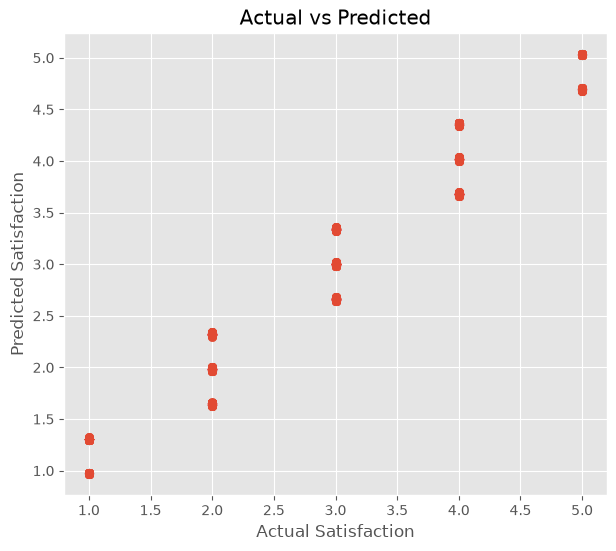

In [16]:
plt.figure(figsize=(7,6))

plt.scatter(

    y_test,

    y_pred

)

plt.xlabel("Actual Satisfaction")

plt.ylabel("Predicted Satisfaction")

plt.title("Actual vs Predicted")

plt.show()

In [17]:
residuals = y_test - y_pred

residuals.head()

11499   -0.331126
6475    -0.017933
13167   -0.311315
862     -0.337709
5970     0.360832
Name: Customer_Satisfaction, dtype: float64

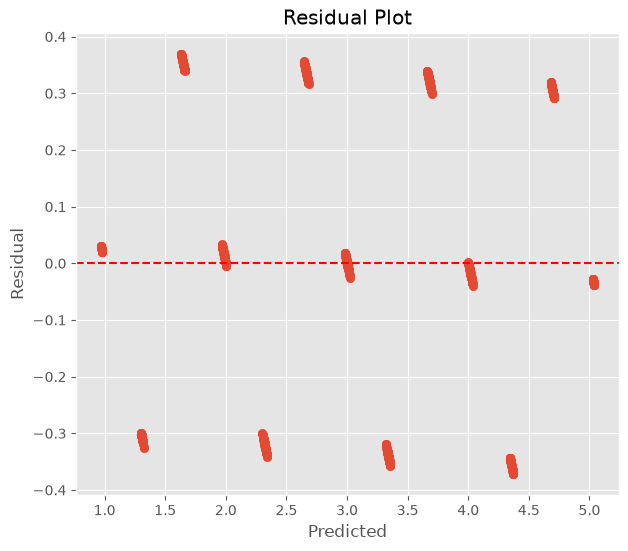

In [18]:
plt.figure(figsize=(7,6))

plt.scatter(

    y_pred,

    residuals

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [19]:
coefficients.sort_values(

    by="Coefficient",

    ascending=False

)

,Feature,Coefficient
1,Service_Quality,0.347436
2,Value_for_Money,0.336445
0,Product_Quality,0.330535
3,Age,0.000244


Business Interpretation

Questions answered

Which factor influences customer satisfaction the most?
Which factor has the smallest impact?
How accurately can customer satisfaction be predicted?
Which variables should management improve first?

Sprint Summary

✔ Simple Linear Regression

✔ Multiple Linear Regression

✔ Train-Test Split

✔ Model Training

✔ Prediction

✔ Regression Coefficients

✔ Intercept

✔ R² Score

✔ Mean Absolute Error (MAE)

✔ Root Mean Squared Error (RMSE)

✔ Residual Analysis

✔ Actual vs Predicted Visualization

✔ Business Interpretation